<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

Mecânica dos Sólidos I

# I.2 Transformação de tensões. Tensões principais. Direções principais.

## Problema 1 <a name="PI21"></a>

Diga o que entende por invariantes do tensor das tensões e determine os invariantes para o tensor das tensões indicado (MPa):

\begin{equation*}
\underline{\underline{\sigma}}^\top =
\begin{bmatrix}
12 & 1 & 0 \\
1 & 6 & 0 \\
0 & 0 & 4
\end{bmatrix}
\end{equation*}


#### Nomenclatura

\begin{equation*}
\begin{aligned}
\sigma_{ij} &\quad \textrm{componentes cartesianas do tensor das tensões em notação indicial, no referencial $S_0$} \\
\sigma_{i'j'} &\quad \textrm{componentes cartesianas do tensor das tensões em notação indicial, no referencial $S_1$} \\
\sigma_{ji}^P &\quad \textrm{matriz da tensões principais} \\
\sigma_{\alpha} &\quad \textrm{tensão principal $\alpha=\mathrm{I,II,III}$} \\
I_i &\quad \textrm{Invariante $i=1,2,3$} \\
\sigma  &\quad \textrm{valor próprio ou tensão principal} \\
\delta_{ij} &\quad \textrm{símbolo de Kronecker em notação indicial} \\
\end{aligned}
\end{equation*}

## Resolução
Os invariantes das tensões são funções escalares das componentes Cartesianas da tensão que são independentes do sistema de eixos coordenados considerado.

1º invariante:

\begin{equation*}
I_1 = \sigma_{xx}+\sigma_{yy}+\sigma_{zz} =\sigma_{x'x'}+\sigma_{y'y'}+\sigma_{z'z'}
\end{equation*}

In [3]:
import numpy as np

def tensortens(sxx,sxy,sxz,syy,syz,szz):
    return np.array([[sxx,sxy,sxz],[sxy,syy,syz],[sxz,syz,szz]])

tt1 = tensortens(12,1,0,6,0,4)
print('Tensor das tenses:\n', tt1)

I1 = tt1[0,0]+tt1[1,1]+tt1[2,2]
print('1º Invariante, I1 (np.trace()):', I1)

Tensor das tenses:
 [[12  1  0]
 [ 1  6  0]
 [ 0  0  4]]
1º Invariante, I1 (np.trace()): 22


2º invariante:

\begin{equation*}
\begin{split}
I_2 & = \sigma_{xx}\sigma_{yy} + \sigma_{yy}\sigma_{zz} + \sigma_{zz}\sigma_{xx}-
\tau_{xy}^2-\tau_{yz}^2-\tau_{zx}^2 \\
& =\sigma_{x'x'}\sigma_{y'y'} + \sigma_{y'y'}\sigma_{z'z'} + \sigma_{z'z'}\sigma_{x'x'}-
\tau_{x'y'}^2-\tau_{y'z'}^2-\tau_{z'x'}^2
\end{split}
\end{equation*}

In [4]:
sxx = tt1[0,0]; syy = tt1[1,1]; szz = tt1[2,2]
sxy = tt1[0,1]; sxz = tt1[0,2]; syz = tt1[1,2]

I2 = sxx*syy + syy*szz + szz*sxx - sxy**2 - syz**2 - sxz**2
print('2º Invariante, I2 :', I2)

2º Invariante, I2 : 143


3º invariante:

\begin{equation*}
\begin{split}
I_3 & = \sigma_{xx}\sigma_{yy}\sigma_{zz} - \sigma_{xx}\tau_{yz}^2 - \sigma_{yy}\tau_{xz}^2-
\sigma_{zz}\tau_{xy}^2 + 2\tau_{xy}\tau_{xz}\tau_{yz}\\
& =\sigma_{x'x'}\sigma_{y'y'}\sigma_{z'z'} - \sigma_{x'x'}\tau_{y'z'}^2 - \sigma_{y'y'}\tau_{x'z'}^2-
\sigma_{z'z'}\tau_{x'y'}^2 + 2\tau_{x'y'}\tau_{x'z'}\tau_{y'z'}
\end{split}
\end{equation*}

In [5]:
I3 = sxx*syy*szz - sxx*syz**2 - syy*sxz**2 - szz*sxy**2 +2*sxy*sxz*syz
print('3º Invariante, I3 :', I3)

3º Invariante, I3 : 284


Mais concretamente, os invariantes do tensor das tensões são coeficientes da equação caraterística do tensor das tensões resultante do desenvolvimento algébrico do seguinte determinante:

\begin{equation*}
|\sigma_{ij}-\sigma\delta_{ij}| = 0
\end{equation*}

cujas raízes definem as tensões principais. Desta forma

\begin{equation*}
\begin{vmatrix}
\sigma_{xx}-\sigma & \sigma_{xy} & \sigma_{xz} \\
\sigma_{yx} & \sigma_{yy}-\sigma & \sigma_{yz} \\
\sigma_{zx} & \sigma_{zy} & \sigma_{zz}-\sigma
\end{vmatrix} = 0
\end{equation*}

A solução desta equação resulta na equação cúbica designada por caraterística do tensor das tensões:

\begin{equation*}
\begin{split}
\sigma^3 & - ~ (\sigma_{xx}+\sigma_{yy}+\sigma_{zz})\sigma^2 \\
 + ~(\sigma_{xx}\sigma_{yy} & + \sigma_{yy}\sigma_{zz} + \sigma_{zz}\sigma_{xx}-
\tau_{xy}^2-\tau_{yz}^2-\tau_{zx}^2)\sigma \\
- ~(\sigma_{xx}\sigma_{yy}\sigma_{zz} & - \sigma_{xx}\tau_{yz}^2 - \sigma_{yy}\tau_{xz}^2-
\sigma_{zz}\tau_{xy}^2 + 2\tau_{xy}\tau_{xz}\tau_{yz}) = 0
\end{split}
\end{equation*}

In [6]:
import sympy as sp
from sympy import collect

s11,s12,s13,s22,s23,s33,S = sp.symbols('s11 s12 s13 s22 s23 s33 S')

M = sp.Matrix(np.array([[s11-S,s12,s13],[s12,s22-S,s23],[s13,s23,s33-S]]))
print('matriz : ',M)
print(' ')
print('Det : ',sp.simplify(sp.expand(M.det())))
print(' ')
print('Det : ',collect(sp.simplify(sp.expand(M.det())),S))

matriz :  Matrix([[-S + s11, s12, s13], [s12, -S + s22, s23], [s13, s23, -S + s33]])
 
Det :  -S**3 + S**2*s11 + S**2*s22 + S**2*s33 - S*s11*s22 - S*s11*s33 + S*s12**2 + S*s13**2 - S*s22*s33 + S*s23**2 + s11*s22*s33 - s11*s23**2 - s12**2*s33 + 2*s12*s13*s23 - s13**2*s22
 
Det :  -S**3 + S**2*(s11 + s22 + s33) + S*(-s11*s22 - s11*s33 + s12**2 + s13**2 - s22*s33 + s23**2) + s11*s22*s33 - s11*s23**2 - s12**2*s33 + 2*s12*s13*s23 - s13**2*s22



ou simplificadamente,

\begin{equation*}
\sigma^3 - I_1\sigma^2 + I_2\sigma - I_3 = 0
\end{equation*}

em que

\begin{equation*}
\begin{aligned}
I_1 &= \mathrm{Tr}(\sigma_{ij}) \\
I_2 &= \frac{1}{2}\left[ \mathrm{Tr}(\sigma_{ij})^2 - \mathrm{Tr}(\sigma_{ij}^2) \right] =
\frac{1}{2}\left( \sigma_{ii}\sigma_{jj} - \sigma_{ij}\sigma_{ji} \right) \\
& =
\begin{vmatrix}
\sigma_{11} & \sigma_{12} \\
\sigma_{21} & \sigma_{22} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{11} & \sigma_{13} \\
\sigma_{31} & \sigma_{33} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{22} & \sigma_{23} \\
\sigma_{32} & \sigma_{33} \\
\end{vmatrix} \\\\
I_3 &= \mathrm{det}(\sigma_{ij}) \\
\end{aligned}
\end{equation*}

Trata-se de uma equação do terceiro grau em $\sigma$, cujas raízes disignam-se por $\sigma_{\mathrm{I}}$, $\sigma_{\mathrm{II}}$ e $\sigma_{\mathrm{III}}$ são as três tensões principais no ponto considerado. Por convenção: $\sigma_{\mathrm{I}} > \sigma_{\mathrm{II}} > \sigma_{\mathrm{III}}$.

In [7]:
I1b = np.trace(tt1)
print('1º Invariante, I1:', '{:.1f}'.format(I1b))

I2b = 0.5*(np.trace(tt1)**2 -np.trace(np.dot(tt1,tt1)))
print('2º Invariante, I2 :', '{:.1f}'.format(I2b))

I3b = np.linalg.det(tt1)
print('3º Invariante, I3 :', '{:.1f}'.format(I3b))

1º Invariante, I1: 22.0
2º Invariante, I2 : 143.0
3º Invariante, I3 : 284.0


**Equação caraterística**


 Resolucao Numerica - Numpy : ............................

 Numpy : roots =  [12.16227766  5.83772234  4.        ]

Tensão principal (valor próprio) sI =  12.16
 Tensão principal (valor próprio) sII =  5.84
Tensão principal (valor próprio) sIII = 4.00


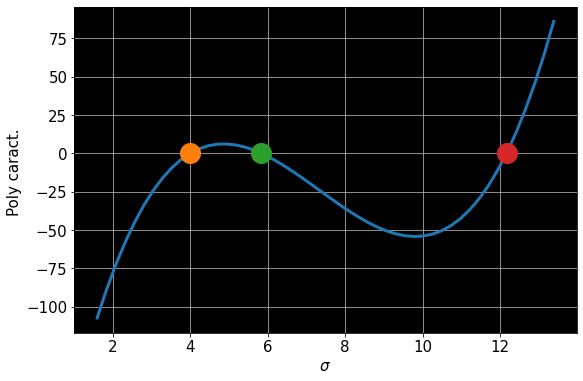

In [8]:
print('\n Resolucao Numerica - Numpy : ............................')
valpropriosN = np.roots([1,-I1,I2,-I3])
print('\n Numpy : roots = ',valpropriosN)
valpropriosN = np.sort(valpropriosN)
sIII = valpropriosN[0]
sII = valpropriosN[1]
sI = valpropriosN[2]
print('\nTensão principal (valor próprio) sI = ','{:.2f}'.format(sI))
print(' Tensão principal (valor próprio) sII = ','{:.2f}'.format(sII))
print('Tensão principal (valor próprio) sIII =','{:.2f}'.format(sIII))

srange = np.linspace(sIII*.4,sI*1.1,50)
def polycaract(s):
    return s**3 - I1*s**2 + I2*s - I3

AAA = polycaract(srange)
import matplotlib.pyplot as plt
font = {'size'   : 15}
plt.rc('font', **font)
plt.rcParams['axes.facecolor']='black'
plt.figure(figsize=(9,6))
plt.plot(srange,polycaract(srange),linewidth=3)
for i in valpropriosN:
    plt.plot(i,polycaract(i),'o',markersize=20)
plt.ylabel('Poly caract. ')
plt.xlabel('$\sigma$')
plt.grid('on')
plt.show()

Em termos das tensões principais têm-se;

\begin{equation*}
\sigma_{ji}^P =
\begin{bmatrix}
\sigma_{\mathrm{I}} & 0 & 0 \\
0 & \sigma_{\mathrm{II}} & 0 \\
0 & 0 & \sigma_{\mathrm{III}}
\end{bmatrix}
\end{equation*}

e

\begin{equation*}
\begin{aligned}
I_1 &= \sigma_{\mathrm{I}}+\sigma_{\mathrm{II}}+\sigma_{\mathrm{III}} \\
I_2 &= \sigma_{\mathrm{I}}\sigma_{\mathrm{II}} + \sigma_{\mathrm{II}}\sigma_{\mathrm{III}}
+ \sigma_{\mathrm{I}}\sigma_{\mathrm{III}} \\
I_3 &= \sigma_{\mathrm{I}}\sigma_{\mathrm{II}}\sigma_{\mathrm{III}} \\
\end{aligned}
\end{equation*}

#### Apêndice A. Determinante de matriz de terceira ordem

Para calcular o determinante de matrizes de terceira ordem:

\begin{equation*}
[A] =
\begin{bmatrix}
a & b & c \\
d & e & f \\
g & h & i
\end{bmatrix}
\end{equation*}

pode utilizar-se a chamada regra de Sarrus, que resulta no seguinte cálculo:

\begin{equation*}
\det([A]) =
\begin{vmatrix}
a & b & c \\
d & e & f \\
g & h & i
\end{vmatrix}
\begin{vmatrix}
a & b  \\
d & e \\
g & h
\end{vmatrix}= (aei + bfg + cdh) - (gec + hfa + idb)
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au02/Au02_P001_i1.png" width="250" height="200">

ou ainda,

\begin{equation*}
\begin{split}
\det([A]) &=
\begin{vmatrix}
a & b & c \\
d & e & f \\
g & h & i
\end{vmatrix} = a
\begin{vmatrix}
e & f \\
h & i
\end{vmatrix} - b
\begin{vmatrix}
d & f \\
g & i
\end{vmatrix} + c
\begin{vmatrix}
d & e \\
g & h
\end{vmatrix} \\
& = a(ei-hf)+b(gf-di) + c(dh-ge)
\end{split}
\end{equation*}

### EigenCalc

<a href="http://www.geo.cornell.edu/geology/faculty/RWA/programs/utility-programs/eigencalc.html" target="_blank"> <span
style="color:#333399"> EigenCalc

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au02/Au02_P001_EigenCalc.jpg"
width="400" height="400">

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
